#### ============================================
###  1. Import Libraries
#### ============================================

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

#### ============================================
###  2. Read a Data
#### ============================================

In [20]:
Data = pd.read_csv("/Users/mac/Desktop/Zain Projects/Task 1 Salary Dataset/data/processed/Cleaned_Salaries.csv")

#### ============================================
###  3. Check a Data
#### ============================================

In [21]:
Data.head()

,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Agency
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,12.028214,0.000000,12.899683,10.262188,13.249166,13.249166,2011,San Francisco
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),11.957400,12.409556,11.833648,10.262188,13.197304,13.197304,2011,San Francisco
2,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),12.267827,11.572035,9.708300,10.262188,12.722724,12.722724,2011,San Francisco
3,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,11.263399,10.935278,12.197576,10.262188,12.713928,12.713928,2011,San Francisco
4,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",11.808595,9.183791,12.113056,10.262188,12.695800,12.695800,2011,San Francisco


In [22]:
Data = Data[Data["BasePay"] > 0].reset_index(drop=True)

#### ============================================
###  4. Feature Enginrring
#### ============================================

### 4.1 Clean & Normalize Text Columns

In [23]:
Data["JobTitle"] = Data["JobTitle"].str.strip().str.upper()
if "Agency" in Data.columns:
    Data["Agency"] = Data["Agency"].str.strip().str.upper()

###  4.2 Features & Target

In [24]:
base_features   = ["JobTitle", "Year"]
numeric_extras  = [col for col in ["OvertimePay", "OtherPay", "Benefits"] if col in Data.columns]
cat_extras      = []

all_features = base_features + numeric_extras + cat_extras
print("Features used:", all_features)

X = Data[all_features].copy()
y = Data["BasePay"]

Features used: ['JobTitle', 'Year', 'OvertimePay', 'OtherPay', 'Benefits']


### 4.3 Train / Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 4.4 Target Encoding

In [26]:
def smooth_target_encode(train_series, train_target, test_series, smoothing=10):
    """
    Target Encoding مع Smoothing
    smoothing: كلما كبر، كلما ازداد تأثير الـ Global Mean للـ categories القليلة
    """
    global_mean = train_target.mean()
    stats = (
        pd.concat([train_series, train_target], axis=1)
        .groupby(train_series.name)[train_target.name]
        .agg(["mean", "count"])
    )
    stats["smooth_mean"] = (
        (stats["count"] * stats["mean"] + smoothing * global_mean)
        / (stats["count"] + smoothing)
    )
    train_encoded = train_series.map(stats["smooth_mean"])
    test_encoded  = test_series.map(stats["smooth_mean"]).fillna(global_mean)
    return train_encoded, test_encoded, stats["smooth_mean"]


# Encode JobTitle
X_train["JobTitle_encoded"], X_test["JobTitle_encoded"], job_map = smooth_target_encode(
    X_train["JobTitle"], y_train.rename("BasePay"), X_test["JobTitle"], smoothing=10
)

# Encode Agency if it exists
if "Agency" in X_train.columns:
    X_train["Agency_encoded"], X_test["Agency_encoded"], agency_map = smooth_target_encode(
        X_train["Agency"], y_train.rename("BasePay"), X_test["Agency"], smoothing=10
    )
    cat_encoded = ["Agency_encoded"]
else:
    agency_map = None
    cat_encoded = []

final_cols = ["JobTitle_encoded", "Year"] + numeric_extras + cat_encoded
X_train_final = X_train[final_cols]
X_test_final  = X_test[final_cols]
print("Final feature columns:", final_cols)

Final feature columns: ['JobTitle_encoded', 'Year', 'OvertimePay', 'OtherPay', 'Benefits']


#### ============================================
###  5. Model
#### ============================================

###  5.1 Build a Model

In [27]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,         
    min_child_samples=20,  
    reg_alpha=0.1,         
    reg_lambda=0.1,        
    subsample=0.8,         
    colsample_bytree=0.8,  
    random_state=42,
    n_jobs=-1
)

### 5.2 K-Fold Cross Validation

In [28]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2_scores   = []
cv_rmse_scores = []

X_arr = X_train_final.values
y_arr = y_train.values

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_arr), 1):
    X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
    y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

    fold_model = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=8,
        num_leaves=63, min_child_samples=20,
        reg_alpha=0.1, reg_lambda=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
    fold_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    preds = fold_model.predict(X_val)
    cv_r2_scores.append(r2_score(y_val, preds))
    cv_rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    print(f"Fold {fold} — R2: {cv_r2_scores[-1]:.4f}  |  RMSE: {cv_rmse_scores[-1]:.4f}")

print(f"\nCV Mean R2:   {np.mean(cv_r2_scores):.4f} ± {np.std(cv_r2_scores):.4f}")
print(f"CV Mean RMSE: {np.mean(cv_rmse_scores):.4f} ± {np.std(cv_rmse_scores):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1013
[LightGBM] [Info] Number of data points in the train set: 94292, number of used features: 5
[LightGBM] [Info] Start training from score 10.703018
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

### 5.3 Train Final Model on Full Training Data

In [29]:
model.fit(
    X_train_final, y_train,
    eval_set=[(X_test_final, y_test)],
    eval_metric="rmse",
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1015
[LightGBM] [Info] Number of data points in the train set: 117865, number of used features: 5
[LightGBM] [Info] Start training from score 10.702648
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 0.567955	valid_0's l2: 0.322573
[100]	valid_0's rmse: 0.472416	valid_0's l2: 0.223177
[150]	valid_0's rmse: 0.452593	valid_0's l2: 0.204841
[200]	valid_0's rmse: 0.444695	valid_0's l2: 0.197754
[250]	valid_0's rmse: 0.439983	valid_0's l2: 0.193585
[300]	valid_0's rmse: 0.436751	valid_0's l2: 0.190752
[350]	valid_0's rmse: 0.433822	valid_0's l2: 0.188202
[400]	valid_0's rmse: 0.431352	valid_0's l2: 0.186064
[450]	valid_0's rmse: 0.429135	valid_0's l2: 0.184156
[500]	valid_0's rmse: 0.427423	valid_0's l2: 0.

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=8,
              n_estimators=1000, n_jobs=-1, random_state=42, reg_alpha=0.1,
              reg_lambda=0.1, subsample=0.8)

###  5.4 Evaluate a Model

In [30]:
y_pred = model.predict(X_test_final)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n--- Evaluation Metrics ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")


--- Evaluation Metrics ---
RMSE: 0.4185
MAE:  0.1899
R2:   0.8862


### 5.5 Feature Importance

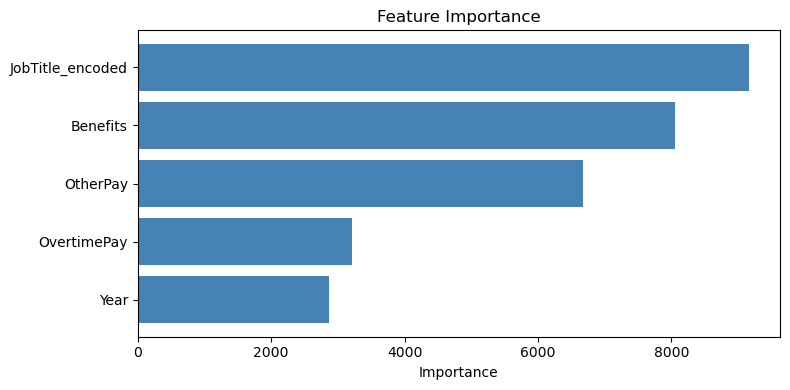

In [31]:
importance_df = pd.DataFrame({
    "Feature":    final_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, max(4, len(final_cols) * 0.6)))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

### 5.6 Actual vs Predicted Plot

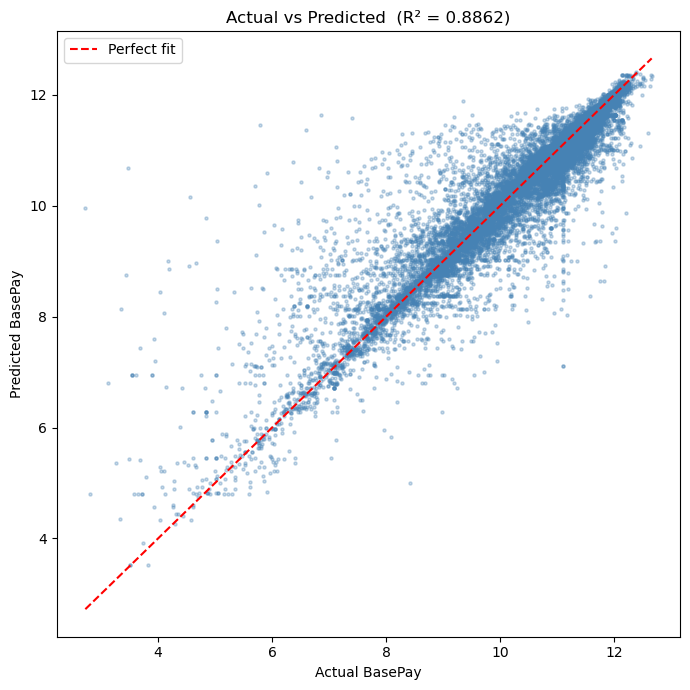

In [32]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=5, color="steelblue")
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect fit")
plt.xlabel("Actual BasePay")
plt.ylabel("Predicted BasePay")
plt.title(f"Actual vs Predicted  (R² = {r2:.4f})")
plt.legend()
plt.tight_layout()
plt.show()

#### ============================================
###  6. Save a Model
#### ============================================

In [33]:
joblib.dump(model,      "salary_model.pkl")
joblib.dump(job_map,    "job_target_map.pkl")
if agency_map is not None:
    joblib.dump(agency_map, "agency_target_map.pkl")
joblib.dump(y_train.mean(), "global_mean.pkl")

print("Saved: salary_model.pkl, job_target_map.pkl, global_mean.pkl")

Saved: salary_model.pkl, job_target_map.pkl, global_mean.pkl
